# 📊 Thống kê dữ liệu Hateful Meme Datasets

Thống kê phân bố **Hateful** vs **Benign** cho 2 dataset:
- **Facebook Hateful Meme** (gốc, từ Facebook AI Challenge 2020)
- **Merged Dataset** (FB + Memotion 7k — dùng cho Phase 2 validation)

In [1]:
import json
import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.size"] = 12

BASE_DIR = os.path.abspath(".")
LABEL_NAMES = {0: "Benign", 1: "Hateful"}

DATASETS = {
    "Facebook Hateful Meme": {
        "data_dir": os.path.join(BASE_DIR, "data"),
        "splits": ["train.jsonl", "dev.jsonl", "test.jsonl"],
    },
    "Memotion 7K": {
        "data_dir": os.path.join(BASE_DIR, "memotion_dataset_7k", "data"),
        "splits": ["train.jsonl", "dev.jsonl", "test.jsonl"],
    },
    "Merged (FB + Memotion)": {
        "data_dir": os.path.join(BASE_DIR, "merge_dataset", "data"),
        "splits": ["train.jsonl", "dev.jsonl", "test.jsonl"],
    },
}


def read_jsonl(filepath):
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def count_labels(records):
    return Counter(r["label"] for r in records)


# Doc tat ca data
data = {}
for ds_name, ds_info in DATASETS.items():
    data[ds_name] = {}
    for split_file in ds_info["splits"]:
        filepath = os.path.join(ds_info["data_dir"], split_file)
        split_name = split_file.replace(".jsonl", "")
        if os.path.exists(filepath):
            records = read_jsonl(filepath)
            data[ds_name][split_name] = count_labels(records)
        else:
            print(f"  [!] Missing: {filepath}")

print("Da doc xong du lieu!")
for ds_name, splits in data.items():
    for split, counter in splits.items():
        print(f"  {ds_name} / {split}: {sum(counter.values()):,} mau")

Da doc xong du lieu!
  Facebook Hateful Meme / train: 8,500 mau
  Facebook Hateful Meme / dev: 500 mau
  Facebook Hateful Meme / test: 1,000 mau
  Memotion 7K / train: 5,593 mau
  Memotion 7K / dev: 699 mau
  Memotion 7K / test: 700 mau
  Merged (FB + Memotion) / train: 11,333 mau
  Merged (FB + Memotion) / dev: 667 mau
  Merged (FB + Memotion) / test: 1,333 mau


---
## 1. Facebook Hateful Meme Dataset

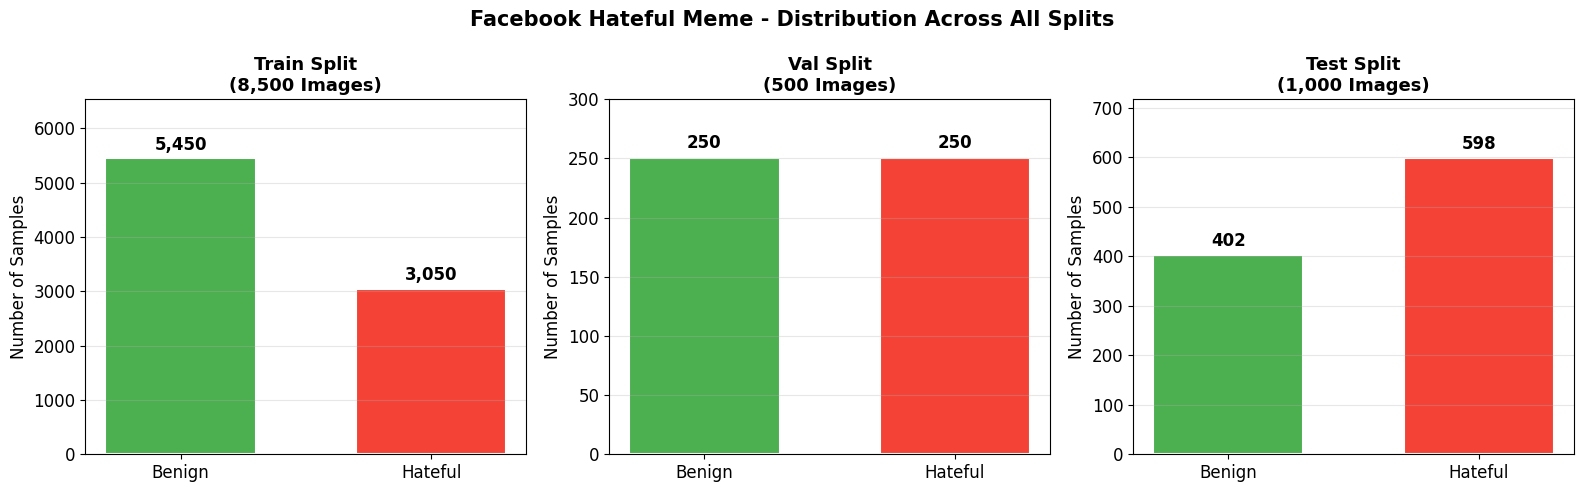

In [2]:
ds = "Facebook Hateful Meme"
split_names = ["train", "dev", "test"]
split_titles = ["Train Split", "Val Split", "Test Split"]
colors = ["#4CAF50", "#F44336"]
class_names = ["Benign", "Hateful"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (split, title) in enumerate(zip(split_names, split_titles)):
    ax = axes[idx]
    counter = data[ds][split]
    total = sum(counter.values())
    values = [counter.get(0, 0), counter.get(1, 0)]

    bars = ax.bar(class_names, values, color=colors, edgecolor="white", linewidth=1.5, width=0.6)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.set_title(f"{title}\n({total:,} Images)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Samples")
    ax.set_ylim(0, max(values) * 1.2)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"{ds} - Distribution Across All Splits", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. Memotion 7K Dataset

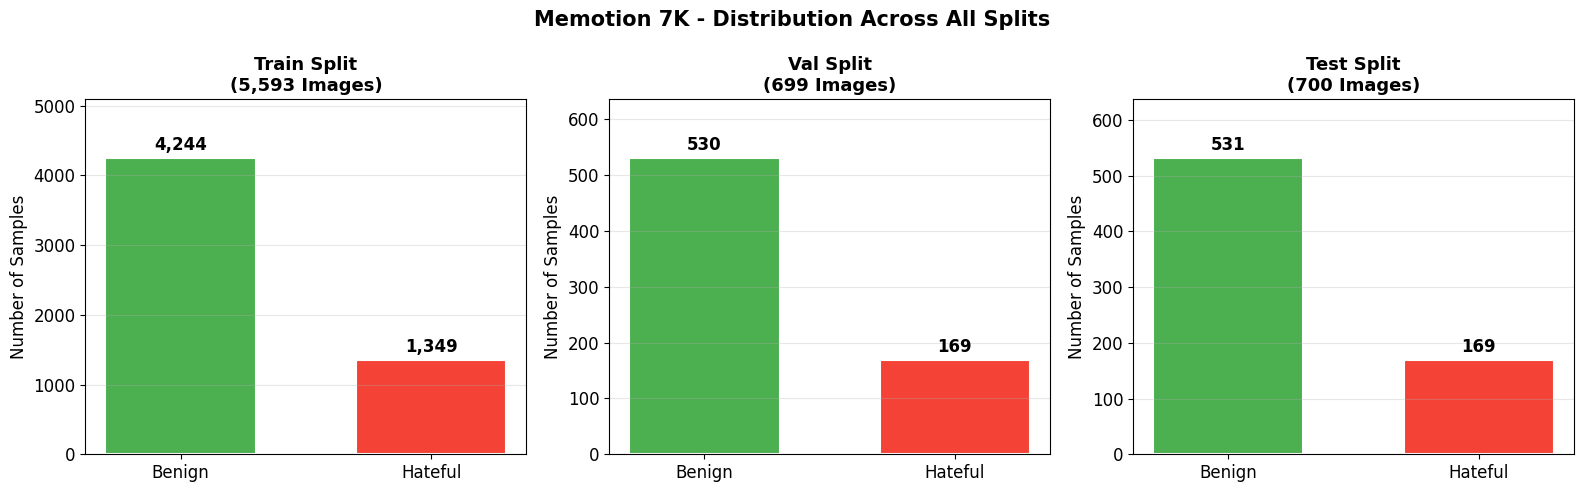

In [3]:
ds = "Memotion 7K"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (split, title) in enumerate(zip(split_names, split_titles)):
    ax = axes[idx]
    counter = data[ds][split]
    total = sum(counter.values())
    values = [counter.get(0, 0), counter.get(1, 0)]

    bars = ax.bar(class_names, values, color=colors, edgecolor="white", linewidth=1.5, width=0.6)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.set_title(f"{title}\n({total:,} Images)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Samples")
    ax.set_ylim(0, max(values) * 1.2)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"{ds} - Distribution Across All Splits", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. Merged Dataset (FB + Memotion)

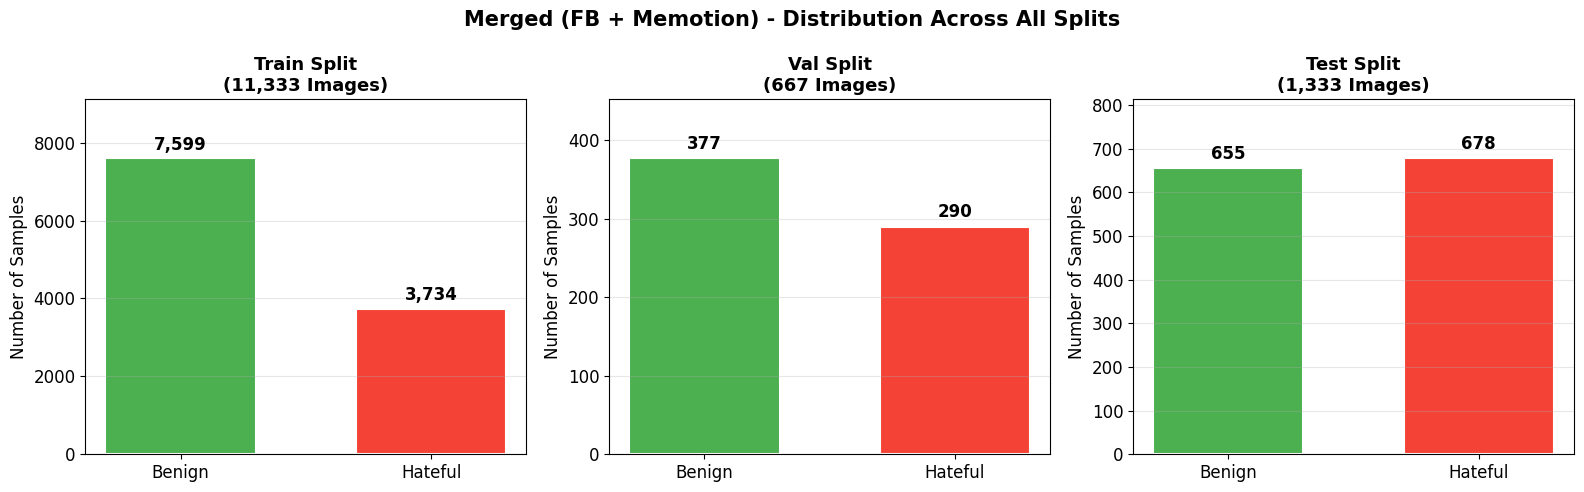

In [4]:
ds = "Merged (FB + Memotion)"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (split, title) in enumerate(zip(split_names, split_titles)):
    ax = axes[idx]
    counter = data[ds][split]
    total = sum(counter.values())
    values = [counter.get(0, 0), counter.get(1, 0)]

    bars = ax.bar(class_names, values, color=colors, edgecolor="white", linewidth=1.5, width=0.6)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.set_title(f"{title}\n({total:,} Images)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Samples")
    ax.set_ylim(0, max(values) * 1.2)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"{ds} - Distribution Across All Splits", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Tổng hợp

In [5]:
print(f"{'Dataset':<25} {'Split':<8} {'Benign':>8} {'Hateful':>8} {'Total':>8} {'% Hateful':>10}")
print("=" * 75)

grand_total = Counter()

for ds_name, splits in data.items():
    ds_counter = Counter()
    for split_name in ["train", "dev", "test"]:
        counter = splits[split_name]
        b, h = counter.get(0, 0), counter.get(1, 0)
        t = b + h
        pct = h / t * 100 if t > 0 else 0
        print(f"{ds_name:<25} {split_name:<8} {b:>8,} {h:>8,} {t:>8,} {pct:>9.1f}%")
        ds_counter += counter
        grand_total += counter
    b, h = ds_counter.get(0, 0), ds_counter.get(1, 0)
    t = b + h
    pct = h / t * 100 if t > 0 else 0
    print(f"{'':>25} {'ALL':<8} {b:>8,} {h:>8,} {t:>8,} {pct:>9.1f}%")
    print("-" * 75)

b, h = grand_total.get(0, 0), grand_total.get(1, 0)
t = b + h
pct = h / t * 100 if t > 0 else 0
print(f"{'GRAND TOTAL':<25} {'':8} {b:>8,} {h:>8,} {t:>8,} {pct:>9.1f}%")

Dataset                   Split      Benign  Hateful    Total  % Hateful
Facebook Hateful Meme     train       5,450    3,050    8,500      35.9%
Facebook Hateful Meme     dev           250      250      500      50.0%
Facebook Hateful Meme     test          402      598    1,000      59.8%
                          ALL         6,102    3,898   10,000      39.0%
---------------------------------------------------------------------------
Memotion 7K               train       4,244    1,349    5,593      24.1%
Memotion 7K               dev           530      169      699      24.2%
Memotion 7K               test          531      169      700      24.1%
                          ALL         5,305    1,687    6,992      24.1%
---------------------------------------------------------------------------
Merged (FB + Memotion)    train       7,599    3,734   11,333      32.9%
Merged (FB + Memotion)    dev           377      290      667      43.5%
Merged (FB + Memotion)    test          655  